# ANN vs CNN: Comparison on MNIST and CIFAR10 Datasets

This notebook implements and compares Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) using PyTorch.
We will go through the following steps for both MNIST and CIFAR10 datasets:
1. Loading and Preprocessing Data
2. Visualizing Random Samples
3. Defining Models (ANN & CNN)
4. Training and Evaluation
5. Plotting Accuracy/Loss Curves
6. Comparing Inference Time

### Importing the necessary libraries

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001

Using device: cpu


## Helper Functions
We define some helper functions for training, evaluation, and visualization to avoid code repetition.

In [2]:
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    train_losses = []
    train_accuracies = []
    
    print(f"Starting training for {epochs} epochs...")
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")
        
    training_time = time.time() - start_time
    print(f"Training finished in {training_time:.2f}s")
    return train_losses, train_accuracies, training_time

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    start_time = time.time()
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    inference_time = time.time() - start_time
    accuracy = 100 * correct / total
    avg_inference_time_ms = (inference_time / total) * 1000
    
    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Inference Time (Total): {inference_time:.4f}s")
    print(f"Inference Time (Per Sample): {avg_inference_time_ms:.4f}ms")
    
    return accuracy, avg_inference_time_ms

def plot_metrics(ann_metrics, cnn_metrics, dataset_name):
    ann_loss, ann_acc, _ = ann_metrics
    cnn_loss, cnn_acc, _ = cnn_metrics
    epochs = range(1, len(ann_loss) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, ann_loss, label='ANN Loss', marker='o')
    plt.plot(epochs, cnn_loss, label='CNN Loss', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{dataset_name} Loss Comparison')
    plt.legend()
    plt.grid(True)
    
    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, ann_acc, label='ANN Accuracy', marker='o')
    plt.plot(epochs, cnn_acc, label='CNN Accuracy', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title(f'{dataset_name} Accuracy Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.show()

def show_random_images(loader, classes, dataset_name):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    
    # Unnormalize
    img = torchvision.utils.make_grid(images[:8])
    img = img / 2 + 0.5
    npimg = img.numpy()
    
    plt.figure(figsize=(10, 5))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Random Samples from {dataset_name}")
    plt.axis('off')
    plt.show()
    
    print('Labels:', ' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

# Part 1: MNIST Dataset

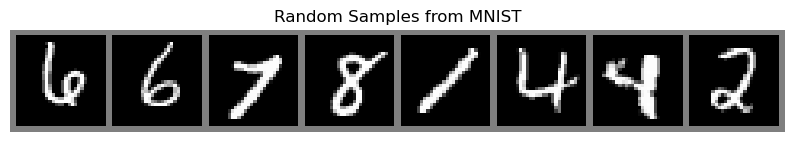

Labels: 6     6     7     8     1     4     4     2    


In [3]:
# Load MNIST Data
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set_mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
test_set_mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

train_loader_mnist = DataLoader(train_set_mnist, batch_size=BATCH_SIZE, shuffle=True)
test_loader_mnist = DataLoader(test_set_mnist, batch_size=BATCH_SIZE, shuffle=False)

classes_mnist = [str(i) for i in range(10)]

# Show samples
show_random_images(train_loader_mnist, classes_mnist, 'MNIST')

### ANN for MNIST
Input size: 28x28 = 784

In [4]:
class ANN_MNIST(nn.Module):
    def __init__(self):
        super(ANN_MNIST, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

ann_mnist = ANN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ann_mnist.parameters(), lr=LEARNING_RATE)

print("Training ANN on MNIST...")
ann_mnist_metrics = train_model(ann_mnist, train_loader_mnist, criterion, optimizer, EPOCHS)
ann_mnist_acc, ann_mnist_time = evaluate_model(ann_mnist, test_loader_mnist)

Training ANN on MNIST...
Starting training for 5 epochs...
Epoch [1/5], Loss: 0.3001, Accuracy: 90.66%
Epoch [2/5], Loss: 0.1342, Accuracy: 95.85%
Epoch [3/5], Loss: 0.1054, Accuracy: 96.70%
Epoch [4/5], Loss: 0.0823, Accuracy: 97.45%
Epoch [5/5], Loss: 0.0706, Accuracy: 97.72%
Training finished in 94.64s
Test Accuracy: 97.10%
Inference Time (Total): 2.2648s
Inference Time (Per Sample): 0.2265ms


### CNN for MNIST

In [5]:
class CNN_MNIST(nn.Module):
    def __init__(self):
        super(CNN_MNIST, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # 28x28 -> pool -> 14x14 -> pool -> 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_mnist = CNN_MNIST().to(device)
optimizer_cnn = optim.Adam(cnn_mnist.parameters(), lr=LEARNING_RATE)

print("Training CNN on MNIST...")
cnn_mnist_metrics = train_model(cnn_mnist, train_loader_mnist, criterion, optimizer_cnn, EPOCHS)
cnn_mnist_acc, cnn_mnist_time = evaluate_model(cnn_mnist, test_loader_mnist)

Training CNN on MNIST...
Starting training for 5 epochs...
Epoch [1/5], Loss: 0.1633, Accuracy: 95.19%
Epoch [2/5], Loss: 0.0456, Accuracy: 98.60%
Epoch [3/5], Loss: 0.0313, Accuracy: 99.00%
Epoch [4/5], Loss: 0.0229, Accuracy: 99.30%
Epoch [5/5], Loss: 0.0183, Accuracy: 99.40%
Training finished in 269.57s
Test Accuracy: 99.09%
Inference Time (Total): 4.3253s
Inference Time (Per Sample): 0.4325ms


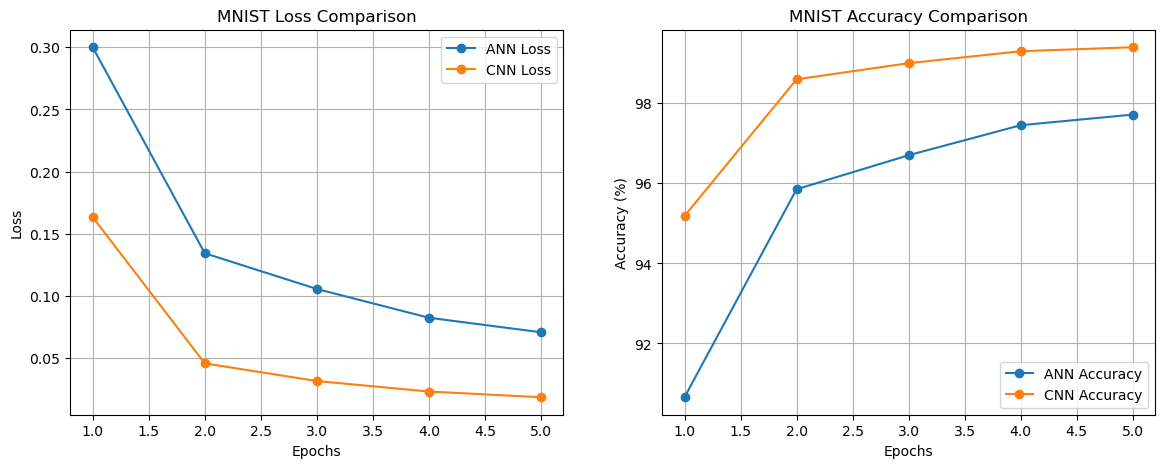

In [6]:
# Compare MNIST Results
plot_metrics(ann_mnist_metrics, cnn_mnist_metrics, 'MNIST')

# Part 2: CIFAR10 Dataset

100%|██████████| 170M/170M [06:30<00:00, 436kB/s]  


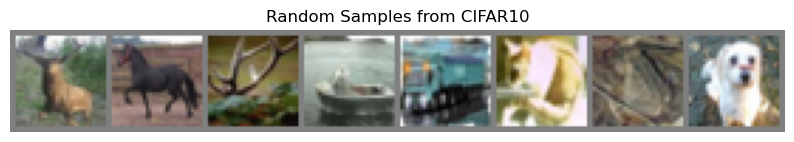

Labels: deer  horse deer  ship  truck cat   frog  dog  


In [7]:
# Load CIFAR10 Data
transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set_cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
test_set_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cifar)

train_loader_cifar = DataLoader(train_set_cifar, batch_size=BATCH_SIZE, shuffle=True)
test_loader_cifar = DataLoader(test_set_cifar, batch_size=BATCH_SIZE, shuffle=False)

classes_cifar = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Show samples
show_random_images(train_loader_cifar, classes_cifar, 'CIFAR10')

### ANN for CIFAR10
Input size: 32x32x3 = 3072

In [8]:
class ANN_CIFAR(nn.Module):
    def __init__(self):
        super(ANN_CIFAR, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

ann_cifar = ANN_CIFAR().to(device)
optimizer_ann_cifar = optim.Adam(ann_cifar.parameters(), lr=LEARNING_RATE)

print("Training ANN on CIFAR10...")
ann_cifar_metrics = train_model(ann_cifar, train_loader_cifar, criterion, optimizer_ann_cifar, EPOCHS)
ann_cifar_acc, ann_cifar_time = evaluate_model(ann_cifar, test_loader_cifar)

Training ANN on CIFAR10...
Starting training for 5 epochs...
Epoch [1/5], Loss: 1.6356, Accuracy: 41.88%
Epoch [2/5], Loss: 1.4258, Accuracy: 49.48%
Epoch [3/5], Loss: 1.3128, Accuracy: 53.65%
Epoch [4/5], Loss: 1.2204, Accuracy: 56.83%
Epoch [5/5], Loss: 1.1384, Accuracy: 59.73%
Training finished in 114.15s
Test Accuracy: 54.04%
Inference Time (Total): 3.3556s
Inference Time (Per Sample): 0.3356ms


### CNN for CIFAR10

In [9]:
class CNN_CIFAR(nn.Module):
    def __init__(self):
        super(CNN_CIFAR, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # 32x32 -> pool -> 16x16 -> pool -> 8x8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_cifar = CNN_CIFAR().to(device)
optimizer_cnn_cifar = optim.Adam(cnn_cifar.parameters(), lr=LEARNING_RATE)

print("Training CNN on CIFAR10...")
cnn_cifar_metrics = train_model(cnn_cifar, train_loader_cifar, criterion, optimizer_cnn_cifar, EPOCHS)
cnn_cifar_acc, cnn_cifar_time = evaluate_model(cnn_cifar, test_loader_cifar)

Training CNN on CIFAR10...
Starting training for 5 epochs...
Epoch [1/5], Loss: 1.3512, Accuracy: 51.45%
Epoch [2/5], Loss: 0.9871, Accuracy: 65.03%
Epoch [3/5], Loss: 0.8308, Accuracy: 70.91%
Epoch [4/5], Loss: 0.7182, Accuracy: 75.01%
Epoch [5/5], Loss: 0.6232, Accuracy: 78.17%
Training finished in 248.59s
Test Accuracy: 69.38%
Inference Time (Total): 6.1373s
Inference Time (Per Sample): 0.6137ms


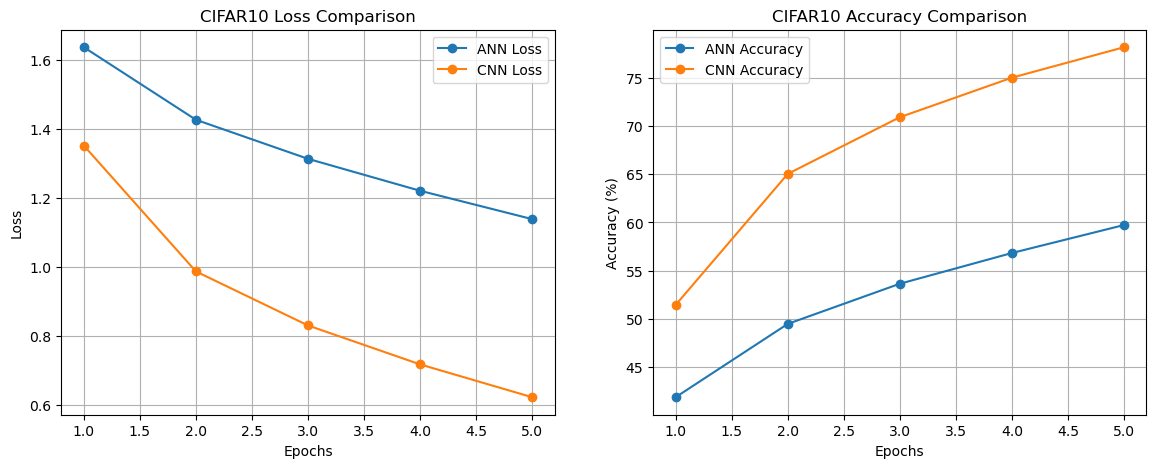

In [10]:
# Compare CIFAR10 Results
plot_metrics(ann_cifar_metrics, cnn_cifar_metrics, 'CIFAR10')

## Final Summary Comparison

In [11]:
print(f"{'Dataset':<10} | {'Model':<10} | {'Test Acc':<10} | {'Inf Time/Sample':<15}")
print("-" * 55)
print(f"{'MNIST':<10} | {'ANN':<10} | {ann_mnist_acc:.2f}%     | {ann_mnist_time:.4f}ms")
print(f"{'MNIST':<10} | {'CNN':<10} | {cnn_mnist_acc:.2f}%     | {cnn_mnist_time:.4f}ms")
print("-" * 55)
print(f"{'CIFAR10':<10} | {'ANN':<10} | {ann_cifar_acc:.2f}%     | {ann_cifar_time:.4f}ms")
print(f"{'CIFAR10':<10} | {'CNN':<10} | {cnn_cifar_acc:.2f}%     | {cnn_cifar_time:.4f}ms")

Dataset    | Model      | Test Acc   | Inf Time/Sample
-------------------------------------------------------
MNIST      | ANN        | 97.10%     | 0.2265ms
MNIST      | CNN        | 99.09%     | 0.4325ms
-------------------------------------------------------
CIFAR10    | ANN        | 54.04%     | 0.3356ms
CIFAR10    | CNN        | 69.38%     | 0.6137ms
